<a href="https://colab.research.google.com/github/robotlover2/deeplearning26.08.10/blob/main/8.10%20DNN_MNIST_%EC%86%90%EA%B8%80%EC%94%A8%EC%88%AB%EC%9E%90%EB%B6%84%EB%A5%98_TF_Keras_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DNN 실습 프로젝트 (1) (학생용 실습본)
# MNIST 손글씨 숫자 분류

---

### 학습 목표

- 이미지를 **숫자 배열**로 확인하고 신경망 입력 형태로 변환할 수 있다.
- `Flatten` + `Dense` 구조의 **DNN 다중 분류 모델**을 구현할 수 있다.
- `softmax` 출력과 `sparse_categorical_crossentropy` 손실의 관계를 설명할 수 있다.
- 오분류 사례를 직접 확인하고 모델의 한계를 설명할 수 있다.

> 3차시와 절차는 완전히 같다. 달라지는 것은 **입력이 표에서 이미지로 바뀐다는 점** 하나뿐이다.

## 이 노트북 사용법 — 학생용 실습본

이 파일은 **핵심 코드가 빈칸(`____`)으로 비워진 실습본**이다.
수업 중 강사의 설명을 들으며 빈칸을 직접 채워 넣는다.

### 진행 방법

1. 코드 셀 위쪽의 **`채울 곳`** 안내 블록을 먼저 읽는다.
2. 코드 안의 `____` 를 찾아 알맞은 값·함수 이름으로 바꾼다. 각 빈칸에는 `①` `②` 번호가 붙어 있다.
3. `Shift + Enter` 로 셀을 실행한다.

### 실행하면 이런 오류가 난다면

| 오류 메시지 | 원인 |
|---|---|
| `NameError: name '____' is not defined` | 아직 채우지 않은 빈칸이 남아 있다 |
| `SyntaxError` | 빈칸을 지우면서 괄호·따옴표를 함께 지웠다 |

> 빈칸이 아닌 부분은 이미 완성되어 있으니 고치지 않아도 된다.
> 막히면 손을 들거나 채팅으로 알리자. 정답본은 수업 후 배포된다.

## 실행 환경 안내

**Google Colab 기준으로 작성한 노트북이다.**

1. 상단 메뉴 `런타임` → `런타임 유형 변경`
2. 하드웨어 가속기를 `T4 GPU` 로 변경 후 저장
3. 위에서부터 순서대로 셀을 실행한다 (`Shift + Enter`)

> 이 노트북은 CPU에서도 1~2분 내에 학습이 끝난다. GPU는 선택 사항이다.

---
## 1.라이브러리 가져오기

In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


---
## 2.① 데이터 로드

MNIST는 - MNIST는 0부터 9까지 숫자 손글씨로 이루어진 표준 데이터셋으로\
28X28사이즈의 60000의 훈련 데이터와 10000개의 테스트 데이터로 구성되어 있습니다.
    - x_train.shape == (60000, 28, 28)  
    - x_test.shape == (10000, 28, 28)  
    - y_train.shape == (60000,)  
    - y_test.shape == (10000,)   

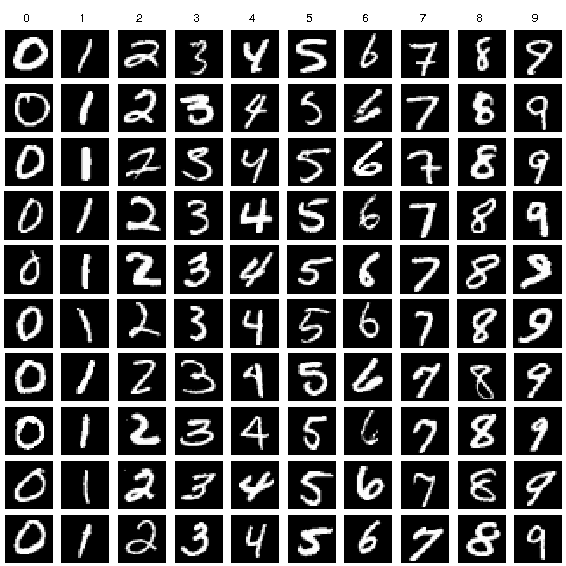

In [5]:
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① Keras에 내장된 손글씨 숫자 데이터셋 이름
# └───────────────────────────────────────────────────────────────

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()   # ①keras에 있는 mnist 숫자 데이터셋

print("학습 이미지 :", x_train.shape, x_train.dtype)
print("학습 정답   :", y_train.shape)
print("테스트 이미지:", x_test.shape)
print("픽셀 값 범위:", x_train.min(), "~", x_train.max())

학습 이미지 : (60000, 28, 28) uint8
학습 정답   : (60000,)
테스트 이미지: (10000, 28, 28)
픽셀 값 범위: 0 ~ 255


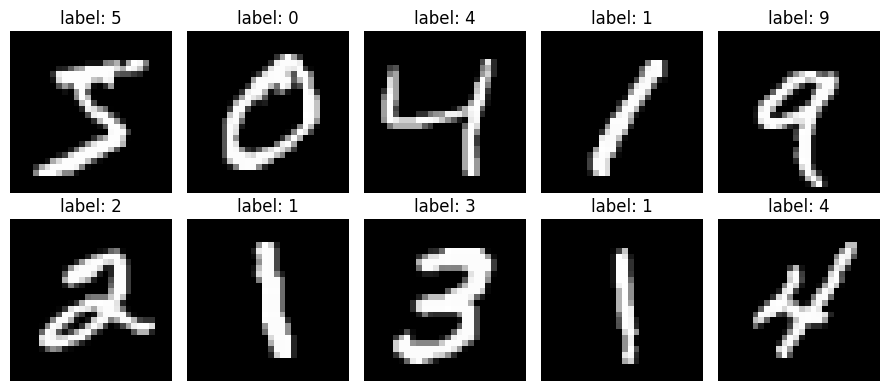

In [7]:

#데이터의 일부를 가져와서 찍어봄
plt.figure(figsize=(9, 4)) #9x4 크기
for i in range(10):
    plt.subplot(2, 5, i + 1) #2열 5행 으로 랜덤하게 하나씩 설정
    # imshow --> 이미지를 보여줌 gray이니깐 흑백으로
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"label: {y_train[i]}")
    plt.axis("off")
    #칼각 정리후 출력
plt.tight_layout(); plt.show()

### 이미지는 정말 숫자 배열인가

아래 셀은 첫 번째 이미지의 일부를 숫자로 출력한다.
**이미지 = (높이, 너비) 모양의 숫자 배열** 이라는 사실을 눈으로 확인하고 넘어간다.
5차시 OpenCV에서 이 개념을 본격적으로 다룬다.

In [8]:
np.set_printoptions(linewidth=200)
print(x_train[0][6:22, 4:24])   # 28x28 중 일부만 출력

[[  0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64]
 [  0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0]
 [  0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   0   0   0   0]
 [  0   0   0   0  80 156 107 253 253 205  11   0  43 154   0   0   0   0   0   0]
 [  0   0   0   0   0  14   1 154 253  90   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 139 253 190   2   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  11 190 253  70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  35 241 225 160 108   1   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  81 240 253 253 119  25   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  45 186 253 253 150  27   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  16  93 252 253 187   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 249 253 249  64   0   0   0]
 [  

---
## 3.② 전처리

전처리 말고 다른 부분은 사진으로 학습 시키기에 필요 없음


1. **정규화** : 0-255 → 0-1 로 나눈다. 값의 범위가 작을수록 학습이 안정적이다.
2. **형태 유지** : `Flatten` 층이 (28, 28) → 784 로 펴 주므로 직접 reshape 할 필요는 없다.

In [9]:
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 픽셀이 가질 수 있는 최댓값(255)으로 나누어 0~1 로 만든다
#    (astype("float32")를 먼저 하지 않으면 정수 나눗셈이 되어 전부 0이 된다)
# └───────────────────────────────────────────────────────────────

x_train = x_train.astype("float32") / 255.0   # ① 최대값으로 나눠서 0과 1사이의 값으로 바꿔줌
x_test  = x_test.astype("float32") / 255.0    # ①

# 검증셋 분리 (학습 6만 중 5천 장)
# 5천장만 검증셋으로 사용
x_val, y_val = x_train[:5000], y_train[:5000]
x_train, y_train = x_train[5000:], y_train[5000:]

print(f"train {x_train.shape[0]} / val {x_val.shape[0]} / test {x_test.shape[0]}")

train 55000 / val 5000 / test 10000


---
## 4.③ 모델 구성 — DNN

| 층 | 역할 |
|---|---|
| `Flatten` | 28×28 이미지를 784개의 1차원 입력으로 편다 |
| `Dense(128, relu)` | 특징을 조합하는 은닉층 |
| `Dropout(0.2)` | 학습 시 뉴런 일부를 꺼서 과적합을 억제 |
| `Dense(10, softmax)` | 클래스 10개에 대한 확률을 출력 (합 = 1) |

In [28]:
# ┌─ 채울 곳 ────────────────────────────────────
# ① 28x28 2차원 이미지를 784개의 1차원 입력으로 펴는 층 이름
# ② 은닉층 활성화 함수 (문자열)
# ③ 출력층 뉴런 수 : 분류할 숫자가 0~9 이므로 몇 개?
# ④ 출력층 활성화 함수 : 합이 1이 되는 확률로 만든다
# └──────────────────────────────────────────

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),         # 픽셀 28x28이 2차원으로 입력됨
    tf.keras.layers.Flatten(),                     # ① 2차원을 1차원으로 바꿔줌 뒤에 Dense 는 1차원만 받기 때문에


    #tf.keras.layers.Input(shape=(28*28,)),
    tf.keras.layers.Dense(128, activation='relu'),   # ②
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),    # ②
    tf.keras.layers.Dense(10, activation='softmax')   # ③ ④
], name="mnist_dnn")

model.summary()

Model: "mnist_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

> **여기서 생각해 볼 점**
> 784개 입력이 128개 뉴런과 모두 연결되면 파라미터가 10만 개를 넘는다.
> 만약 입력이 224×224 컬러 이미지라면? 150,528 × 128 ≈ **1,900만 개** 가 된다.
> 이 문제가 2일차 CNN이 등장하는 이유다.

---
## 5.④ 학습 설정

정답이 `0~9` 정수 형태이므로 `sparse_categorical_crossentropy` 를 쓴다.
정답을 원-핫 벡터로 바꿔 두었다면 `categorical_crossentropy` 를 쓴다. 계산 결과는 같다.

In [29]:
# ┌─ 채울 곳 ──────────────────────────────────────
# ① 손실 함수 : 정답이 0~9 '정수'인 다중 분류용 crossentropy (문자열)
#    힌트 - 라벨이 원-핫이 아니라 정수 하나일 때 쓰는 이름이 따로 있다
# └────────────────────────────────────────────

model.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',   # ① 다중분류일 때는 이걸 사용
    metrics=["accuracy"]
)

---
## 6.⑤ 학습

In [30]:
# ┌─ 채울 곳 ─────────────────────────────────────
# ① 반복 학습 횟수 : 15
# ② 한 번에 묶어 계산할 이미지 개수 : 128
# └───────────────────────────────────────────
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,        # ①
    batch_size=128,    # ② 이미지라서 ㅈㄴ 많이 묶어야 함  데이터 양이 어마함
    verbose=1
)

Epoch 1/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8760 - loss: 0.4182 - val_accuracy: 0.9526 - val_loss: 0.1689
Epoch 2/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9466 - loss: 0.1776 - val_accuracy: 0.9630 - val_loss: 0.1225
Epoch 3/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9604 - loss: 0.1302 - val_accuracy: 0.9704 - val_loss: 0.1019
Epoch 4/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9680 - loss: 0.1059 - val_accuracy: 0.9744 - val_loss: 0.0873
Epoch 5/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9732 - loss: 0.0872 - val_accuracy: 0.9758 - val_loss: 0.0832
Epoch 6/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9763 - loss: 0.0766 - val_accuracy: 0.9776 - val_loss: 0.0788
Epoch 7/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9785 - loss: 0.0685 - val_accuracy: 0.9770 - val_loss: 0.0757
Epoch 8/15
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9802 - loss: 0.0622 - val_accuracy: 0.

---
## 7.⑥ 학습 과정 살펴보기

In [25]:
import matplotlib.pyplot as plt

def plot_history(history, title=""):
    """학습 곡선(손실 · 정확도)을 나란히 그린다."""
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    ax[0].plot(h["loss"], label="train")
    if "val_loss" in h:
        ax[0].plot(h["val_loss"], label="validation")
    ax[0].set_title(f"{title} Loss")
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend(); ax[0].grid(alpha=.3)

    acc_key = "accuracy" if "accuracy" in h else "acc"
    ax[1].plot(h[acc_key], label="train")
    if "val_" + acc_key in h:
        ax[1].plot(h["val_" + acc_key], label="validation")
    ax[1].set_title(f"{title} Accuracy")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].legend(); ax[1].grid(alpha=.3)

    plt.tight_layout(); plt.show()

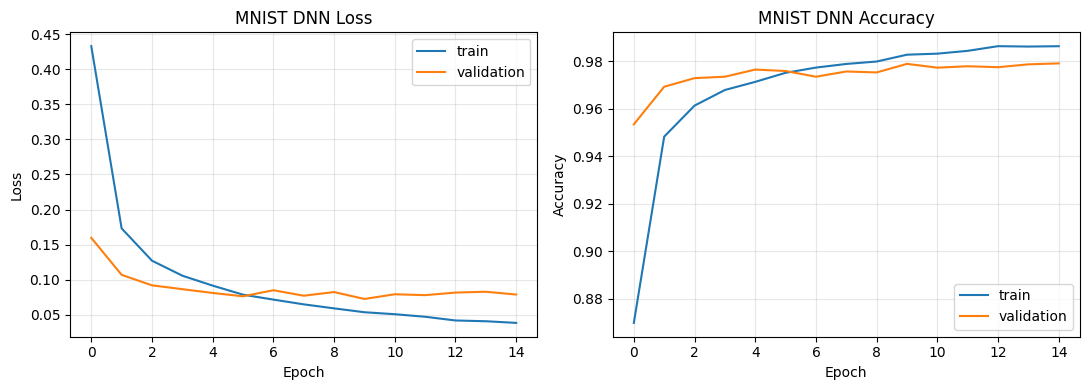

In [26]:
plot_history(history, "MNIST DNN")

---
## 8.평가 및 예측

In [31]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"테스트 정확도: {acc:.4f}  (손실 {loss:.4f})")

테스트 정확도: 0.9785  (손실 0.0795)


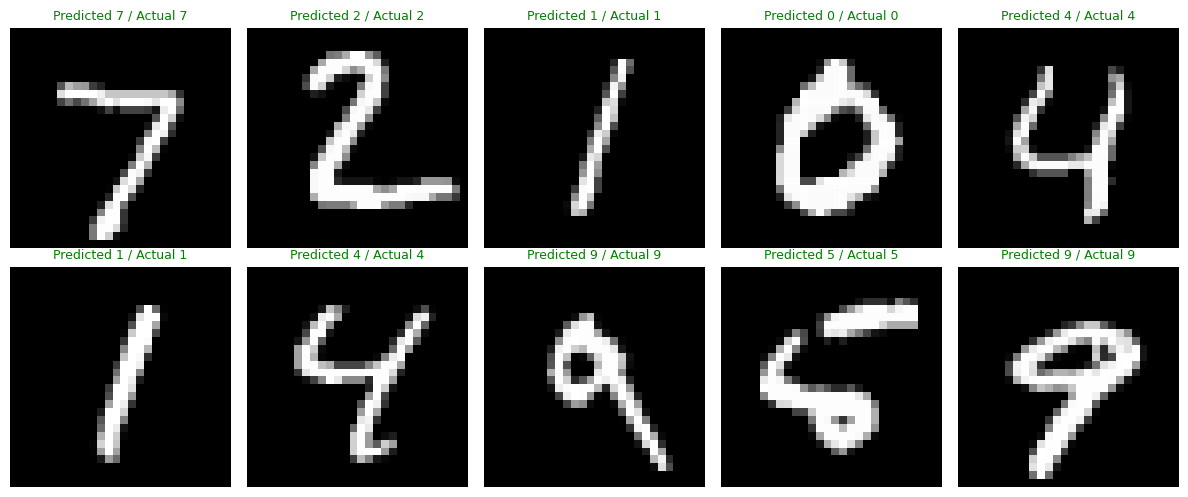

In [ ]:
# ┌─ 채울 곳 ────────────────────────────────────
# ① 모델 출력은 (이미지 개수, 10) 모양의 확률 배열이다.
#    각 행에서 가장 큰 값의 '위치'를 찾아야 하므로 어느 축을 기준으로? → 1
# └─────────────────────────────────────────

y_prob = model.predict(x_test, verbose=0)
y_pred = y_prob.argmax(axis=1)   # ①

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    ok = y_pred[i] == y_test[i]
    plt.title(f"Predicted {y_pred[i]} / Actual {y_test[i]}", color="green" if ok else "red", fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

### 틀린 것만 모아 보기

정확도 97%는 **100장 중 3장을 틀린다**는 뜻이다. 무엇을 틀렸는지 보는 것이 성능 숫자보다 중요하다.

오분류 개수: 198 / 10000


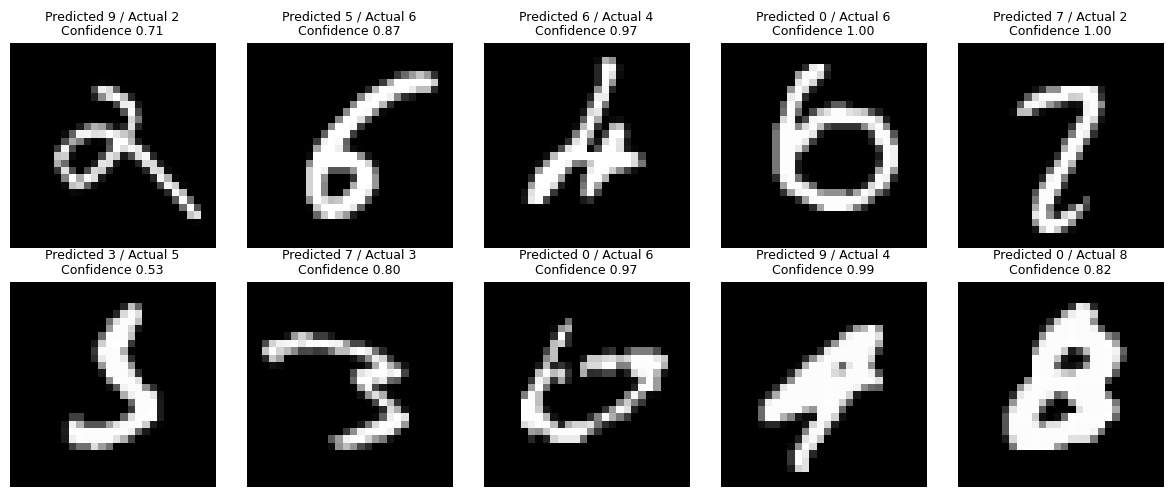

In [ ]:
wrong = np.where(y_pred != y_test)[0]
print(f"오분류 개수: {len(wrong)} / {len(y_test)}")

plt.figure(figsize=(12, 5))
for i, idx in enumerate(wrong[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(f"Predicted {y_pred[idx]} / Actual {y_test[idx]}\nConfidence {y_prob[idx].max():.2f}", fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

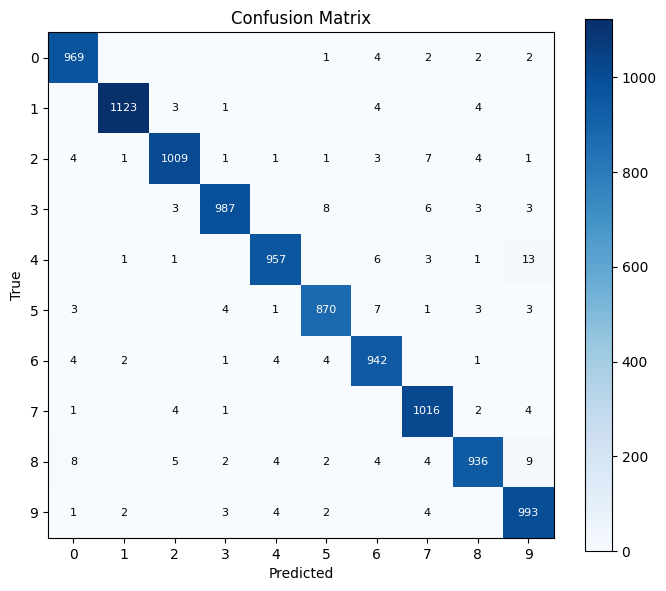

              precision    recall  f1-score   support

           0      0.979     0.989     0.984       980
           1      0.995     0.989     0.992      1135
           2      0.984     0.978     0.981      1032
           3      0.987     0.977     0.982      1010
           4      0.986     0.975     0.980       982
           5      0.980     0.975     0.978       892
           6      0.971     0.983     0.977       958
           7      0.974     0.988     0.981      1028
           8      0.979     0.961     0.970       974
           9      0.966     0.984     0.975      1009

    accuracy                          0.980     10000
   macro avg      0.980     0.980     0.980     10000
weighted avg      0.980     0.980     0.980     10000



In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(range(10)); plt.yticks(range(10))
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            plt.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, digits=3))

---
## 9.모델 저장

In [ ]:
model.save("mnist_dnn.keras")
print("저장 완료 : mnist_dnn.keras")

저장 완료 : mnist_dnn.keras


---
## 10. 스스로 해보기

| # | 실험 | 기록할 것 |
|---|---|---|
| 1 | `Dense(128)` → `Dense(512)` | 파라미터 수 / 정확도 / 학습 시간 |
| 2 | 은닉층을 3개로 늘리기 | 깊게 쌓으면 항상 좋아지는가 |
| 3 | 정규화(`/255.0`)를 빼고 학습 | 손실 곡선의 차이 |
| 4 | `Dropout` 제거 후 30 epoch 학습 | 과적합이 나타나는 시점 |
| 5 | 활성화 함수 `relu` → `sigmoid` | 수렴 속도 비교 |

**기록표**

| 실험 | 은닉층 구성 | 파라미터 수 | 테스트 정확도 |학습시간|
|---|---|---|---|---|
| 기본 | 128-64 |109,386 |테스트 정확도: 0.9785  (손실 0.0795) |1~2min|
| 실험 1 |512-64 | 435,402| 0.9822  (손실 0.0743) |1~2min
| 실험 2 |128-96 |111,146 | 테스트 정확도: 0.9768  (손실 0.0877)|1~2min
> 이 표는 2일차 7차시에서 **CNN 결과와 나란히 비교**할 때 다시 사용한다. 반드시 남겨 둘 것.

In [15]:
#1

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),         # 픽셀 28x28이 2차원으로 입력됨
    tf.keras.layers.Flatten(),                     # ① 2차원을 1차원으로 바꿔줌 뒤에 Dense 는 1차원만 받기 때문에
    #tf.keras.layers.Input(shape=(28*28,)),

    tf.keras.layers.Dense(512, activation='relu'),   # ②
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),    # ②
    tf.keras.layers.Dense(10, activation='softmax')   # ③ ④
], name="mnist_dnn_test1")
model.summary()


Model: "mnist_dnn_test1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,402 (1.66 MB)

 Trainable params: 435,402 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#2
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),         # 픽셀 28x28이 2차원으로 입력됨
    tf.keras.layers.Flatten(),                     # ① 2차원을 1차원으로 바꿔줌 뒤에 Dense 는 1차원만 받기 때문에
    #tf.keras.layers.Input(shape=(28*28,)),

    tf.keras.layers.Dense(128, activation='relu'),   # ②
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),    # ②
    tf.keras.layers.Dense(32, activation='relu'),    # ②
    tf.keras.layers.Dense(10, activation='softmax')   # ③ ④
], name="mnist_dnn_test1")
model.summary()


Model: "mnist_dnn_test1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)